In [6]:
from HARMES.config import base_path

from glob import glob
import h5py
from sklearn.preprocessing import StandardScaler
import shelve
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from copy import copy
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = ["acc_" + x for x in "xyz"] + ["gyro_" + x for x in "xyz"]


def get_audio(rec_path):
    x = glob(rec_path + "/*H5.h5")[0]
    return h5py.File(x)

def get_labels(rec_path):
    return glob(rec_path + "/*[0-9][0-9][0-9][0-9][0-9].csv")[0]

def get_puck(rec_path):
    return glob(rec_path + "/*_merged.csv")[0]

def get_watch(rec_path):
    return glob(rec_path + "/recording*_[0-9][0-9].csv")[0]


# In[7]:


def get_participants(base_path):
    return glob(base_path + "/*")

def get_recordings(part_path):
    return glob(part_path + "/*")

In [7]:
def get_humid_response(df, label_df, columns=["humid", "temp", "press"]):
    out = []
    for label in label_df.Description.unique():
        l_df = label_df[label_df.Description==label]
        starts = l_df[l_df["Type"] == "start"].ts_sync
        stops  = l_df[l_df["Type"] == "end"].ts_sync
        for start, stop in zip(starts, stops):
            single_df = df[(df.ts_sync > start) & (df.ts_sync < stop)]
            single_df["label"] = label
            single_df = single_df.reset_index()
            single_df["index_pos"] = single_df.index
            try:
                for col in columns:
                    single_df[col] = single_df[col] - single_df[col].iloc[0]
            except:
                print(single_df, label)
                continue
            if single_df["humid"].std() == 0:
                print("0 std")
                continue
                
            
            out.append(single_df[columns + ["label", "index_pos"]])
    return out

In [8]:



def load_one_recording(recording):
    scaler = StandardScaler()
    label_df = pd.read_csv(get_labels(recording))
    label_df = clean_label_df(label_df)

    df = pd.read_csv(get_puck(recording))
    df["time"] = pd.to_timedelta(df["ts_sync"], unit="ms")
    df = df.set_index("time")
    df = (
        df.select_dtypes(include="number")
        .resample("20ms")
        .mean()
        .interpolate()
    )
    df[feature_cols] = scaler.fit_transform(df[feature_cols])

    df2 = pd.read_csv(get_watch(recording))
    df2["time"] = pd.to_timedelta(df2["ts_sync"], unit="ms")
    df2 = df2.set_index("time")
    df2 = (
        df2.select_dtypes(include="number")
        .resample("20ms")
        .mean()
        .interpolate()
    )
    df2[feature_cols] = scaler.fit_transform(df2[feature_cols])

    af = get_audio(recording)
    ad = af["audio"]
    ad = np.array(ad).astype(np.float32) / 32768.0

    return df, df2, ad, label_df


def clean_label_df(label_df):
    label_df["ts_sync"] = (label_df.Time - label_df.Time.iloc[0]) * 1000
    label_df = label_df[~label_df["Description"].str.contains("deleted", na=False)]
    label_df = label_df.iloc[1:]
    return label_df


def handle_split_recordings(rec1, rec2):
    label_df1 = pd.read_csv(get_labels(rec1))
    label_df1 = clean_label_df(label_df1)
    label_df2 = pd.read_csv(get_labels(rec2))
    task_list = pd.read_csv(glob(rec1 + "/*TASKLIST.csv")[0])

    # Find the checkpoint, at which the split happened, by looking at the first 5 entries of the second recording's labels
    seq = label_df2[label_df2.Type == "end"].Description.to_list()[:4]
    tl = task_list.TASKS.to_list()
    ind = [i for i in range(len(tl)) if tl[i:i + len(seq)] == seq][0]
    # The last recording should end with these 5 (which were conducted before the checkpoint)
    end_seq = tl[ind - 5:ind - 1]
    labels_1 = label_df1[label_df1.Type == "end"].Description.to_list()
    indices = label_df1[label_df1.Type == "end"].index
    # Match the sequence to an index
    ind = [i + len(end_seq) - 1 for i in range(len(labels_1)) if labels_1[i:i + len(end_seq)] == end_seq][0]

    # calculate timestamp for end of first recording.
    last_line1 = label_df1.loc[indices[ind]]
    last_ts = last_line1.ts_sync + 1000

    df1, df2, ad, label_df = load_one_recording(rec1)
    df1 = df1[df1.ts_sync < last_ts]
    df2 = df2[df2.ts_sync < last_ts]
    ad = ad[:int(44100 * last_ts / 1000)]
    return (df1, df2, ad, label_df), load_one_recording(rec2)




humid_by_label_dfs = []
label_dfs = []

for j, part_path in enumerate(tqdm(sorted(get_participants(base_path)))):
    print(part_path)
    part = part_path[-2:]
    recordings = get_recordings(part_path)
    datas = []
    labels = []
    for recording in recordings:
        rec = recording[-4:]
        if rec[-1] == "4":
            continue  # don't load last recording for now.
        try:
            df, df2, ad, label_df = load_one_recording(recording)
            new_humid_dfs = get_humid_response(df, label_df)
            for df in new_humid_dfs:
                humid_by_label_dfs.append(df)
            label_df["Participant"] = part
            label_df["Recording"]= rec
            label_dfs.append(label_df)
        except Exception as e:
            print(f"recording: {recording}:", e)
            rec1 = recording + "/" + recording[-4:] + "01"
            rec2 = recording + "/" + recording[-4:] + "02"
            print("recordings: ", rec1, rec2)
            r1, r2 = handle_split_recordings(rec1, rec2)
            for df, df2, ad, label_df in [r1, r2]:
                new_humid_dfs = get_humid_response(df, label_df)
                label_df["Participant"] = part
                label_df["Recording"]= rec
                label_dfs.append(label_df)
                for df in new_humid_dfs:
                    humid_by_label_dfs.append(df)
            print("split data combined successfully")

  0%|          | 0/20 [00:00<?, ?it/s]

AudioDS/Dataset/Records/01
AudioDS/Dataset/Records/02
AudioDS/Dataset/Records/03
AudioDS/Dataset/Records/04
AudioDS/Dataset/Records/05
recording: AudioDS/Dataset/Records/05/0501: list index out of range
recordings:  AudioDS/Dataset/Records/05/0501/050101 AudioDS/Dataset/Records/05/0501/050102
0 std
0 std
0 std
0 std
0 std
0 std
0 std
0 std
0 std
0 std
0 std
0 std
Empty DataFrame
Columns: [time, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, message, timestamp, temp, press, humid, button, beacon, ts_sync, label, index_pos]
Index: [] Brushing teeth
0 std
0 std
0 std
0 std
0 std
Empty DataFrame
Columns: [time, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, message, timestamp, temp, press, humid, button, beacon, ts_sync, label, index_pos]
Index: [] Window cleaning
Empty DataFrame
Columns: [time, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, message, timestamp, temp, press, humid, button, beacon, ts_sync, label, index_pos]
Index: [] Window cleaning
0 std
0 std
0 std
Empty DataFrame
Columns: [tim

In [9]:
all_df = pd.concat(humid_by_label_dfs)

In [10]:
sns.set_style("whitegrid")

  0%|          | 0/15 [00:00<?, ?it/s]

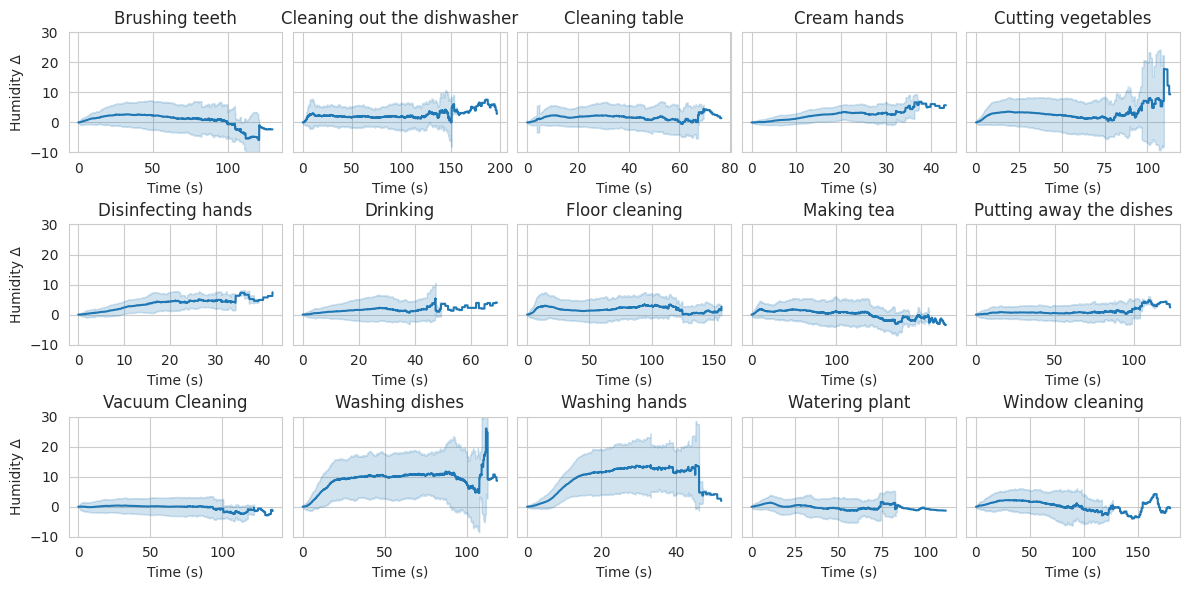

In [11]:
fig, axes = plt.subplots(3, 5, sharey=True, figsize=(12, 6))  #, sharex=True)


for i,(l, act_df) in enumerate(tqdm(all_df.groupby("label"))):
    ax = axes.flat[i]
    act_df.index_pos /= 50
    sns.lineplot(data=act_df, x="index_pos", y="humid", errorbar="sd", ax=ax)
    ax.set_title(l)
    ax.set_ylim(-10,30)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Humidity Δ")
    ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.05)

plt.savefig("hum_resp.pdf")
plt.show()

In [12]:
df = all_df

reset_points = df['index_pos'] == 0

# shift to mark the row BEFORE each reset
end_of_segment = reset_points.shift(-1, fill_value=False)

# select those rows
result = df.loc[end_of_segment, ['index_pos', 'label']]


  0%|          | 0/15 [00:00<?, ?it/s]

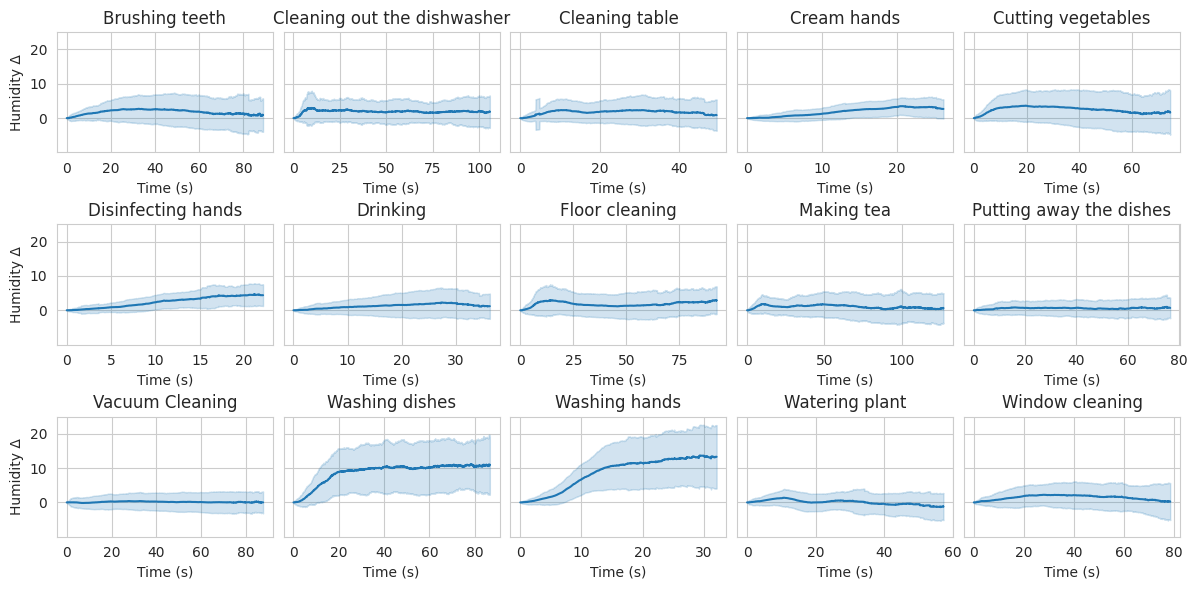

In [13]:
fig, axes = plt.subplots(3, 5, sharey=True, figsize=(12, 6))  #, sharex=True)


for i,(l, act_df) in enumerate(tqdm(all_df.groupby("label"))):
    act_df = act_df[act_df.index_pos < result.groupby("label").describe()["index_pos", "75%"].loc[l]]
    ax = axes.flat[i]
    act_df.index_pos /= 50
    sns.lineplot(data=act_df, x="index_pos", y="humid", errorbar="sd", ax=ax)
    ax.set_title(l)
    ax.set_ylim(-10,25)
    yticks = [0,10,20]
    ax.set_yticks(yticks, labels=yticks)
    
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Humidity Δ")
    ax.grid(True)


plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.05)

plt.savefig("hum_resp.pdf")
plt.show()

  0%|          | 0/15 [00:00<?, ?it/s]

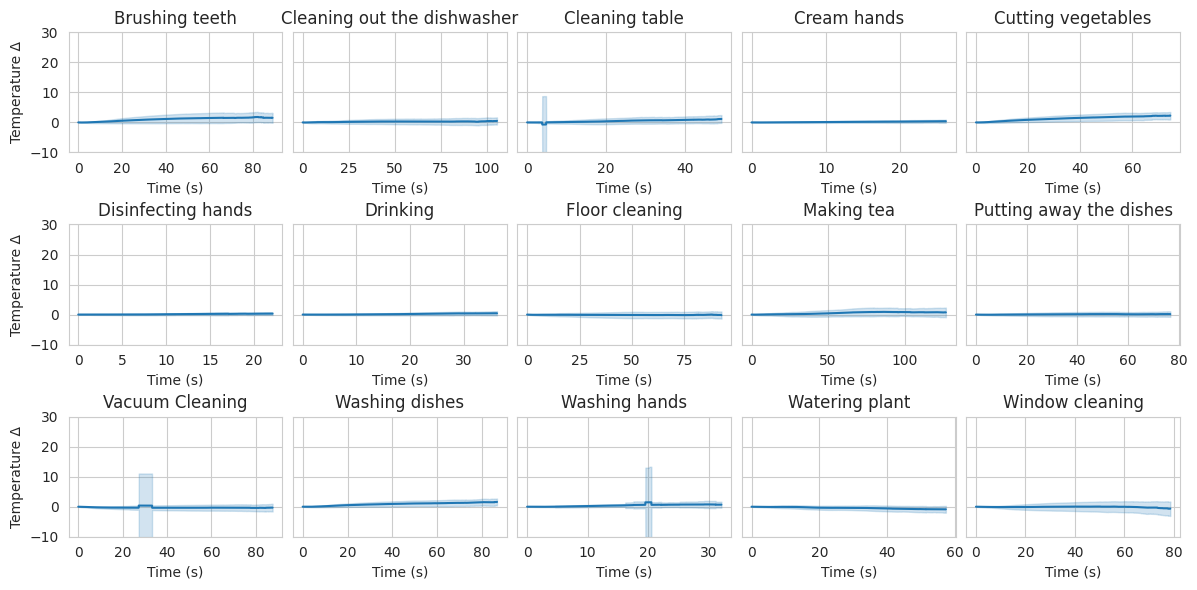

In [14]:
fig, axes = plt.subplots(3, 5, sharey=True, figsize=(12, 6))  #, sharex=True)


for i,(l, act_df) in enumerate(tqdm(all_df.groupby("label"))):
    act_df = act_df[act_df.index_pos < result.groupby("label").describe()["index_pos", "75%"].loc[l]]
    ax = axes.flat[i]
    act_df.index_pos /= 50
    sns.lineplot(data=act_df, x="index_pos", y="temp", errorbar="sd", ax=ax)
    ax.set_title(l)
    ax.set_ylim(-10,30)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temperature Δ")
    ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.05)

plt.savefig("temp_resp.pdf")
plt.show()

  0%|          | 0/15 [00:00<?, ?it/s]

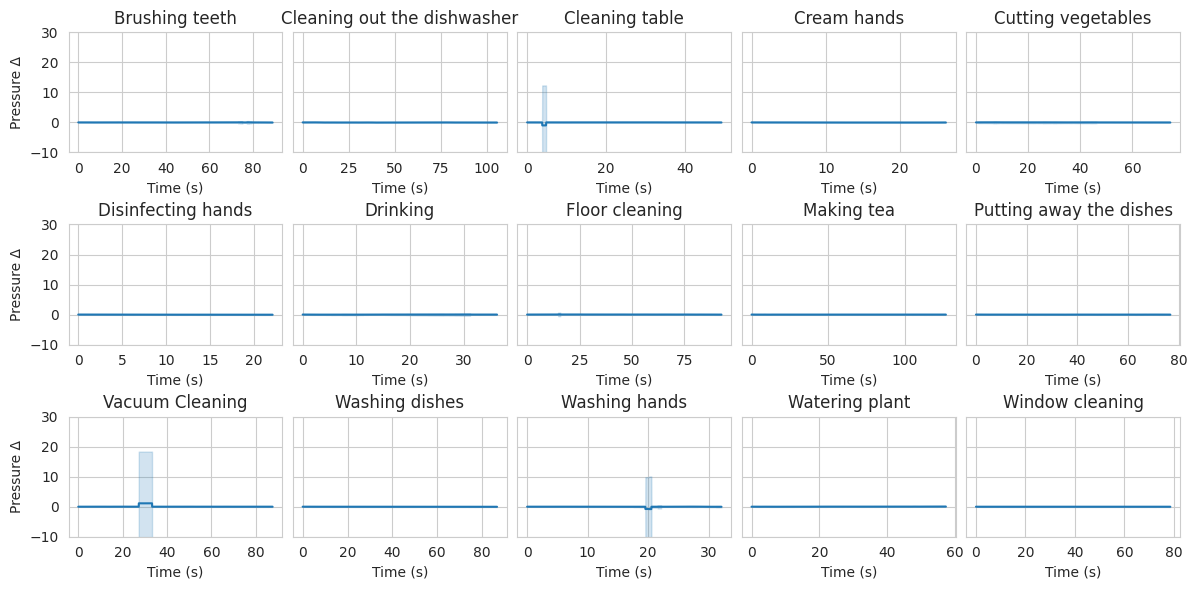

In [15]:
fig, axes = plt.subplots(3, 5, sharey=True, figsize=(12, 6))  #, sharex=True)


for i,(l, act_df) in enumerate(tqdm(all_df.groupby("label"))):
    act_df = act_df[act_df.index_pos < result.groupby("label").describe()["index_pos", "75%"].loc[l]]
    ax = axes.flat[i]
    act_df.index_pos /= 50
    sns.lineplot(data=act_df, x="index_pos", y="press", errorbar="sd", ax=ax)
    ax.set_title(l)
    ax.set_ylim(-10,30)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pressure Δ")
    ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.05)

plt.savefig("press_resp.pdf")
plt.show()

In [16]:
label_dfs[:4]

[            Time   Type      Description       ts_sync Participant Recording
 1   1.753780e+09  start   Floor cleaning  3.013041e+02          01      0101
 2   1.753780e+09    end   Floor cleaning  9.037776e+04          01      0101
 3   1.753780e+09  start  Window cleaning  1.014523e+05          01      0101
 4   1.753780e+09    end  Window cleaning  1.557100e+05          01      0101
 5   1.753780e+09  start   Washing dishes  1.657470e+05          01      0101
 ..           ...    ...              ...           ...         ...       ...
 90  1.753784e+09    end   Cleaning table  3.601045e+06          01      0101
 91  1.753784e+09  start   Washing dishes  3.621181e+06          01      0101
 92  1.753784e+09    end   Washing dishes  3.681491e+06          01      0101
 93  1.753784e+09  start       Making tea  3.763948e+06          01      0101
 94  1.753784e+09    end       Making tea  3.829246e+06          01      0101
 
 [94 rows x 6 columns],
             Time   Type              

In [17]:
last_rec = "00"
for df in sorted(label_dfs, key=lambda x : x.Recording.iloc[0]):
    rec = df.Recording.iloc[0][-2:]
    if rec != "01" or rec == "01" and last_rec == "01":
        df.ts_sync += t
    last_rec = rec
    
    t = df.ts_sync.iloc[-1]

In [18]:
label_dfs[0].head(n=6)

,Time,Type,Description,ts_sync,Participant,Recording
1,1.753780e+09,start,Floor cleaning,301.304102,01,0101
2,1.753780e+09,end,Floor cleaning,90377.758741,01,0101
3,1.753780e+09,start,Window cleaning,101452.316761,01,0101
4,1.753780e+09,end,Window cleaning,155709.990978,01,0101
5,1.753780e+09,start,Washing dishes,165747.011662,01,0101
6,1.753780e+09,end,Washing dishes,250073.229074,01,0101


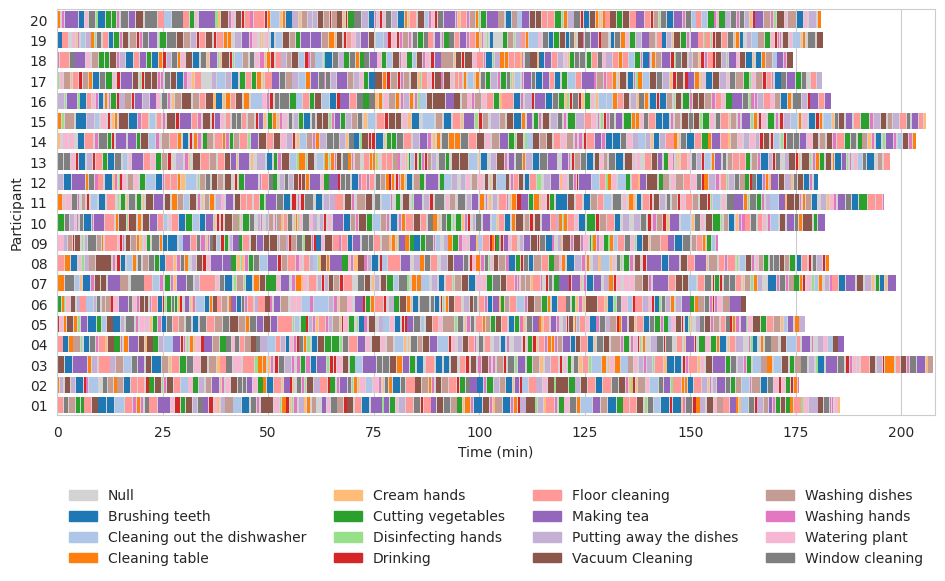

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sort data
df = pd.concat(label_dfs)
df = df.sort_values(["Participant", "ts_sync"])
df.ts_sync /= 60000

# --- Build intervals ---
intervals = []

for participant, group in df.groupby("Participant"):
    stack = {}

    for _, row in group.iterrows():
        key = row["Description"]

        if row["Type"] == "start":
            stack[key] = row["ts_sync"]
        elif row["Type"] == "end" and key in stack:
            start = stack.pop(key)
            end = row["ts_sync"]

            intervals.append({
                "Participant": participant,
                "start": start,
                "end": end,
                "activity": key
            })

interval_df = pd.DataFrame(intervals)

# --- Colors ---
activities = sorted(interval_df["activity"].unique())
cmap = plt.get_cmap("tab20")

color_map = {
    act: cmap(i % 20) for i, act in enumerate(activities)
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

participants = sorted(interval_df["Participant"].unique())

for i, p in enumerate(participants):
    pdata = interval_df[interval_df["Participant"] == p].sort_values("start")

    last_end = 0

    for _, row in pdata.iterrows():
        # GAP (null class)
        if row["start"] > last_end:
            ax.barh(
                y=i,
                width=row["start"] - last_end,
                left=last_end,
                color="lightgray",
                edgecolor="none"
            )

        # ACTIVITY
        ax.barh(
            y=i,
            width=row["end"] - row["start"],
            left=row["start"],
            color=color_map[row["activity"]],
            edgecolor="none"
        )

        last_end = row["end"]

# --- Axis formatting ---
ax.set_yticks(range(len(participants)))
ax.set_yticklabels(participants)

# IMPORTANT: make "01" appear at the TOP
ax.invert_yaxis()

ax.set_xlabel("Time (min)")
ax.set_ylabel("Participant")

# --- Legend (NULL FIRST) ---
null_patch = plt.Rectangle((0, 0), 1, 1, color="lightgray")

activity_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color_map[a])
    for a in activities
]

handles = [null_patch] + activity_patches
labels = ["Null"] + activities
ax.set_xlim(0,208)
ax.set_ylim(-0.5,19.5)

ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),  # move below plot
    ncol=4,                       # <-- controls layout (adjust!)
    frameon=False
)
ax.grid(False)
ax.grid(True, axis="x")
plt.tight_layout()
plt.savefig("part_timeline.pdf", bbox_inches="tight")
plt.show()


In [20]:
ax.get_ylim()

(np.float64(-0.5), np.float64(19.5))

In [21]:
label_df

,Time,Type,Description,ts_sync,Participant,Recording
1,1.775317e+09,start,Vacuum Cleaning,3.982133e+06,20,2002
2,1.775317e+09,end,Vacuum Cleaning,4.055607e+06,20,2002
3,1.775317e+09,start,Cream hands,4.068699e+06,20,2002
4,1.775317e+09,end,Cream hands,4.093921e+06,20,2002
5,1.775317e+09,start,Drinking,4.100976e+06,20,2002
...,...,...,...,...,...,...
90,1.775320e+09,end,Cleaning table,7.242578e+06,20,2002
91,1.775320e+09,start,Putting away the dishes,7.260691e+06,20,2002
92,1.775320e+09,end,Putting away the dishes,7.346277e+06,20,2002
93,1.775320e+09,start,Window cleaning,7.353311e+06,20,2002


In [22]:
drinks = dict()
for j, part_path in enumerate(tqdm(sorted(get_participants(base_path)))):
    print(part_path)
    part = part_path[-2:]
    recordings = get_recordings(part_path)
    for recording in recordings:
        rec = recording[-4:]
        if rec[-1] != "4":
            continue  # don't load last recording for now.
        try:
            label_df = pd.read_csv(get_labels(recording))
            label_df["Participant"] = part
            label_df["Recording"]= rec
            drinks[part] = drinks.get(part, 0) + len(label_df[(label_df.Description=="Drinking")&(label_df.Type=="start")])
           
        except Exception as e:
            print("nope", part, e)
            continue
            print(f"recording: {recording}:", e)
            rec1 = recording + "/" + recording[-4:] + "01"
            rec2 = recording + "/" + recording[-4:] + "02"
            for recording in [rec1, rec2]:
                label_df = pd.read_csv(get_labels(recording))
                label_df["Participant"] = part
                label_df["Recording"]= rec
                drinks[part] = drinks.get(part, 0) + len(label_df[(label_df.Description=="Drinking")&(label_df.Type=="start")])
            print("split data combined successfully")

  0%|          | 0/20 [00:00<?, ?it/s]

AudioDS/Dataset/Records/01
AudioDS/Dataset/Records/02
AudioDS/Dataset/Records/03
AudioDS/Dataset/Records/04
AudioDS/Dataset/Records/05
AudioDS/Dataset/Records/06
AudioDS/Dataset/Records/07
AudioDS/Dataset/Records/08
AudioDS/Dataset/Records/09
AudioDS/Dataset/Records/10
AudioDS/Dataset/Records/11
AudioDS/Dataset/Records/12
AudioDS/Dataset/Records/13
AudioDS/Dataset/Records/14
AudioDS/Dataset/Records/15
AudioDS/Dataset/Records/16
AudioDS/Dataset/Records/17
AudioDS/Dataset/Records/18
AudioDS/Dataset/Records/19
AudioDS/Dataset/Records/20


In [23]:
drinks

{'01': 0,
 '02': 0,
 '03': 1,
 '04': 1,
 '05': 0,
 '06': 0,
 '07': 0,
 '08': 0,
 '09': 0,
 '10': 0,
 '11': 0,
 '12': 1,
 '13': 0,
 '14': 0,
 '15': 0,
 '16': 0,
 '17': 1,
 '18': 0,
 '19': 0,
 '20': 0}